In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub, os

path = kagglehub.dataset_download("manh123df/deap-dataset")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'deap-dataset' dataset.
Path to dataset files: /kaggle/input/deap-dataset


In [3]:
import pickle
import numpy as np
import glob

EEG_CHANNELS = 32
FS = 128
BASELINE_SEC = 3
def load_subject(filepath):
    with open(filepath, "rb") as f:
        d = pickle.load(f, encoding="latin1")
    data = d["data"]
    labels = d["labels"]
    return data, labels

subject_files = sorted(glob.glob(os.path.join(path, "**", "s*.dat"), recursive=True))
print(f"Found {len(subject_files)} subject files")
assert len(subject_files) > 0, "No .dat files found — inspect Cell 2's output and fix the glob pattern / loader."

data0, labels0 = load_subject(subject_files[0])
print("data shape:", data0.shape, "labels shape:", labels0.shape)


Found 32 subject files
data shape: (40, 40, 8064) labels shape: (40, 4)


In [4]:
import pickle as _pkl
data0, labels0 = load_subject(subject_files[0]) if False else (None, None)  # placeholder, real load below
import pickle as _pkl
with open(subject_files[0], "rb") as f:
    d0 = _pkl.load(f, encoding="latin1")

print("Keys:", list(d0.keys()))
print("data shape (trials, channels, samples):", d0["data"].shape)
print("labels shape (trials, [valence, arousal, dominance, liking]):", d0["labels"].shape)
print("dtype:", d0["data"].dtype)
print("any NaNs in data:", np.isnan(d0["data"]).any())
print("any NaNs in labels:", np.isnan(d0["labels"]).any())
print("labels range: min", d0["labels"].min(axis=0), "max", d0["labels"].max(axis=0))


Keys: ['labels', 'data']
data shape (trials, channels, samples): (40, 40, 8064)
labels shape (trials, [valence, arousal, dominance, liking]): (40, 4)
dtype: float64
any NaNs in data: False
any NaNs in labels: False
labels range: min [0.   1.   2.04 3.87] max [8.27 8.15 9.   8.47]


In [5]:
subject_trial_counts = []
for fp in subject_files:
    with open(fp, "rb") as f:
        dd = _pkl.load(f, encoding="latin1")
    subject_trial_counts.append(dd["data"].shape[0])

print(f"Subjects found: {len(subject_files)}")
print(f"Trials per subject: {set(subject_trial_counts)}  (expect all subjects to match, e.g. {{40}})")


Subjects found: 32
Trials per subject: {40}  (expect all subjects to match, e.g. {40})


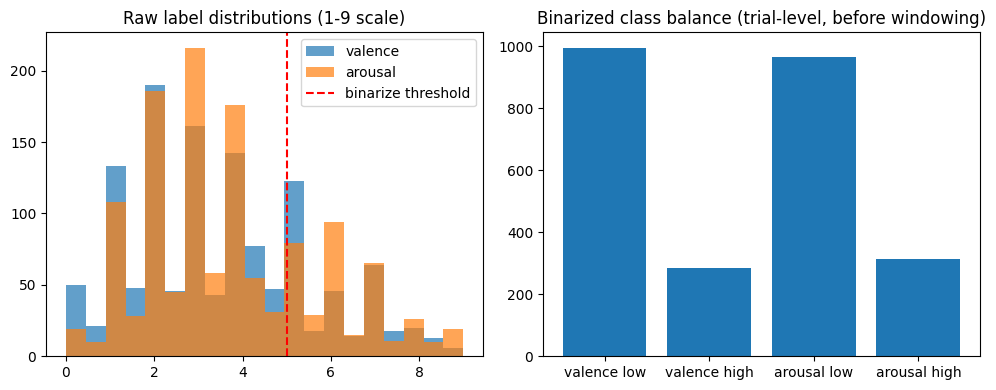

Valence: [995 285] (low/high)  |  Arousal: [965 315] (low/high)


In [6]:
import matplotlib.pyplot as plt

all_raw_labels = []
for fp in subject_files:
    with open(fp, "rb") as f:
        dd = _pkl.load(f, encoding="latin1")
    all_raw_labels.append(dd["labels"])
all_raw_labels = np.concatenate(all_raw_labels, axis=0)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(all_raw_labels[:, 0], bins=20, alpha=0.7, label="valence")
axes[0].hist(all_raw_labels[:, 1], bins=20, alpha=0.7, label="arousal")
axes[0].axvline(5, color="red", linestyle="--", label="binarize threshold")
axes[0].set_title("Raw label distributions (1-9 scale)")
axes[0].legend()

val_bin = (all_raw_labels[:, 0] >= 5).astype(int)
aro_bin = (all_raw_labels[:, 1] >= 5).astype(int)
axes[1].bar(["valence low", "valence high", "arousal low", "arousal high"],
            [np.sum(val_bin == 0), np.sum(val_bin == 1), np.sum(aro_bin == 0), np.sum(aro_bin == 1)])
axes[1].set_title("Binarized class balance (trial-level, before windowing)")
plt.tight_layout()
plt.show()

print(f"Valence: {np.bincount(val_bin)} (low/high)  |  Arousal: {np.bincount(aro_bin)} (low/high)")


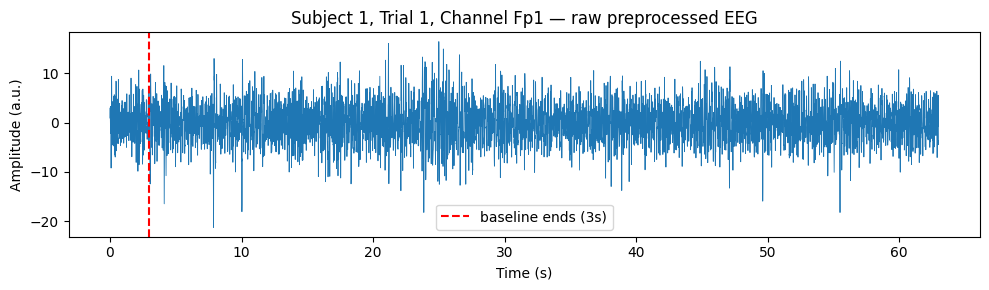

Amplitude stats -- mean: -0.028258582130643233 std: 3.8894215516563397 min: -21.300120846926255 max: 16.481104245964808


In [7]:
with open(subject_files[0], "rb") as f:
    d0 = _pkl.load(f, encoding="latin1")

trial0_ch0 = d0["data"][0, 0, :]
t = np.arange(len(trial0_ch0)) / 128.0

plt.figure(figsize=(10, 3))
plt.plot(t, trial0_ch0, linewidth=0.6)
plt.axvline(3, color="red", linestyle="--", label="baseline ends (3s)")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude (a.u.)")
plt.title("Subject 1, Trial 1, Channel Fp1 — raw preprocessed EEG")
plt.legend(); plt.tight_layout(); plt.show()

print("Amplitude stats -- mean:", trial0_ch0.mean(), "std:", trial0_ch0.std(),
      "min:", trial0_ch0.min(), "max:", trial0_ch0.max())


In [8]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import trapezoid
from multiprocessing import Pool, cpu_count
import itertools, os

BANDS = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "low_beta": (13, 20),
    "high_beta": (20, 30),
    "gamma": (30, 45),
}
WINDOW_SEC = 4
WINDOW_SAMPLES = WINDOW_SEC * FS
WINDOW_STRIDE = WINDOW_SAMPLES // 2  # 50% overlap -> ~2x more training windows
LABEL_THRESHOLD = 5.0
MAX_SUBJECTS = len(subject_files)  # use all 32 subjects instead of only 19: more data = better generalization

def bandpower(sig, fs, band):
    f, pxx = welch(sig, fs=fs, nperseg=min(len(sig), 256))
    lo, hi = band
    idx = (f >= lo) & (f <= hi)
    if not np.any(idx):
        return 0.0
    return float(trapezoid(pxx[idx], f[idx]))

def extract_features_for_trial(trial_eeg):
    T = trial_eeg.shape[1]
    starts = list(range(0, T - WINDOW_SAMPLES + 1, WINDOW_STRIDE))
    freq_feats, raw_windows = [], []
    for start in starts:
        seg = trial_eeg[:, start:start + WINDOW_SAMPLES].astype(np.float32)
        # Per-channel window normalization keeps the raw branch numerically stable.
        seg = (seg - seg.mean(axis=1, keepdims=True)) / (seg.std(axis=1, keepdims=True) + 1e-8)
        wf = np.zeros((EEG_CHANNELS, len(BANDS)), dtype=np.float32)
        for ch in range(EEG_CHANNELS):
            for b_idx, band in enumerate(BANDS.values()):
                wf[ch, b_idx] = bandpower(seg[ch], FS, band)
        freq_feats.append(np.log1p(wf).astype(np.float32))
        raw_windows.append(seg)
    return raw_windows, freq_feats

def _process_single_trial_data(args):
    eeg_data_for_trial, valence_label, arousal_label, s_idx = args
    raw_list, freq_list = extract_features_for_trial(eeg_data_for_trial)
    return [
        {"raw": raw, "freq": freq, "yv": valence_label, "ya": arousal_label, "subject": s_idx}
        for raw, freq in zip(raw_list, freq_list)
    ]

# The old cache contains only frequency features, so it is not sufficient for the
# dual-domain D-STGT model. Rebuild it automatically when raw windows are absent.
CACHED_FEATURES_FILE = "deap_eeg_features_v2.npz"  # new cache name: window scheme changed (overlap + all subjects)

def build_feature_cache():
    tasks = []
    for s_idx, fpath in enumerate(subject_files[:MAX_SUBJECTS]):
        data, labels = load_subject(fpath)
        baseline_samples = BASELINE_SEC * FS
        for trial_idx in range(data.shape[0]):
            eeg = data[trial_idx, :EEG_CHANNELS, baseline_samples:]
            yv = int(labels[trial_idx, 0] >= LABEL_THRESHOLD)
            ya = int(labels[trial_idx, 1] >= LABEL_THRESHOLD)
            tasks.append((eeg, yv, ya, s_idx))

    # Use all available CPU cores for multiprocessing
    nproc = cpu_count()
    print(f"Extracting {len(tasks)} trials with {nproc} worker(s)...")
    with Pool(processes=nproc) as pool:
        results = pool.map(_process_single_trial_data, tasks)

    flat = list(itertools.chain.from_iterable(results))
    all_raw = np.stack([x["raw"] for x in flat]).astype(np.float32)
    all_X = np.stack([x["freq"] for x in flat]).astype(np.float32)
    all_y_valence = np.asarray([x["yv"] for x in flat], dtype=np.int64)
    all_y_arousal = np.asarray([x["ya"] for x in flat], dtype=np.int64)
    all_subjects = np.asarray([x["subject"] for x in flat], dtype=np.int64)

    np.savez_compressed(
        CACHED_FEATURES_FILE,
        all_raw=all_raw, all_X=all_X,
        all_y_valence=all_y_valence, all_y_arousal=all_y_arousal,
        all_subjects=all_subjects
    )
    return all_raw, all_X, all_y_valence, all_y_arousal, all_subjects

if os.path.exists(CACHED_FEATURES_FILE):
    cached = np.load(CACHED_FEATURES_FILE)
    required = {"all_raw", "all_X", "all_y_valence", "all_y_arousal", "all_subjects"}
    if required.issubset(cached.files) and cached["all_X"].shape[-1] == len(BANDS):
        print(f"Loading compatible cache: {CACHED_FEATURES_FILE}")
        all_raw = cached["all_raw"]
        all_X = cached["all_X"]
        all_y_valence = cached["all_y_valence"]
        all_y_arousal = cached["all_y_arousal"]
        all_subjects = cached["all_subjects"]
    else:
        print("Existing cache is incompatible with the current feature settings; rebuilding...")
        all_raw, all_X, all_y_valence, all_y_arousal, all_subjects = build_feature_cache()
else:
    all_raw, all_X, all_y_valence, all_y_arousal, all_subjects = build_feature_cache()

print("Raw tensor:", all_raw.shape, "[windows, 32, 512]")
print("Frequency tensor:", all_X.shape, f"[windows, 32, {len(BANDS)}]")
print("Valence balance:", np.bincount(all_y_valence, minlength=2))
print("Arousal balance:", np.bincount(all_y_arousal, minlength=2))
print("Subjects:", len(np.unique(all_subjects)))

Extracting 1280 trials with 2 worker(s)...
Raw tensor: (37120, 32, 512) [windows, 32, 512]
Frequency tensor: (37120, 32, 5) [windows, 32, 5]
Valence balance: [28855  8265]
Arousal balance: [27985  9135]
Subjects: 32


In [9]:

from sklearn.model_selection import GroupShuffleSplit

# Split by subject, never by individual windows, to prevent subject leakage.
groups = all_subjects
dummy_y = all_y_valence

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
trainval_idx, test_idx = next(gss_test.split(all_X, dummy_y, groups=groups))

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx_rel, val_idx_rel = next(
    gss_val.split(all_X[trainval_idx], dummy_y[trainval_idx], groups=groups[trainval_idx])
)
train_idx = trainval_idx[train_idx_rel]
val_idx = trainval_idx[val_idx_rel]

assert set(groups[train_idx]).isdisjoint(groups[val_idx])
assert set(groups[train_idx]).isdisjoint(groups[test_idx])
assert set(groups[val_idx]).isdisjoint(groups[test_idx])

raw_train, raw_val, raw_test = all_raw[train_idx], all_raw[val_idx], all_raw[test_idx]
freq_train, freq_val, freq_test = all_X[train_idx], all_X[val_idx], all_X[test_idx]
yv_train, yv_val, yv_test = all_y_valence[train_idx], all_y_valence[val_idx], all_y_valence[test_idx]
ya_train, ya_val, ya_test = all_y_arousal[train_idx], all_y_arousal[val_idx], all_y_arousal[test_idx]

# Normalize using training subjects only.
raw_mean = raw_train.mean(axis=(0, 2), keepdims=True)
raw_std = raw_train.std(axis=(0, 2), keepdims=True) + 1e-8
raw_train = (raw_train - raw_mean) / raw_std
raw_val = (raw_val - raw_mean) / raw_std
raw_test = (raw_test - raw_mean) / raw_std

freq_mean = freq_train.mean(axis=(0, 1), keepdims=True)
freq_std = freq_train.std(axis=(0, 1), keepdims=True) + 1e-8
freq_train = (freq_train - freq_mean) / freq_std
freq_val = (freq_val - freq_mean) / freq_std
freq_test = (freq_test - freq_mean) / freq_std

print(f"Train: {len(train_idx)} windows, subjects={sorted(set(groups[train_idx]))}")
print(f"Val:   {len(val_idx)} windows, subjects={sorted(set(groups[val_idx]))}")
print(f"Test:  {len(test_idx)} windows, subjects={sorted(set(groups[test_idx]))}")


Train: 23200 windows, subjects=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(11), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(31)]
Val:   5800 windows, subjects=[np.int64(0), np.int64(10), np.int64(13), np.int64(20), np.int64(28)]
Test:  8120 windows, subjects=[np.int64(8), np.int64(9), np.int64(15), np.int64(17), np.int64(24), np.int64(29), np.int64(30)]


In [10]:
CHANNEL_NAMES = ["Fp1","AF3","F3","F7","FC5","FC1","C3","T7","CP5","CP1","P3","P7","PO3","O1","Oz","Pz",
                  "Fp2","AF4","Fz","F4","F8","FC6","FC2","Cz","C4","T8","CP6","CP2","P4","P8","PO4","O2"]

POS_2D = {
    "Fp1": (-0.3, 0.95), "Fp2": (0.3, 0.95), "AF3": (-0.25, 0.75), "AF4": (0.25, 0.75),
    "F7": (-0.85, 0.55), "F3": (-0.45, 0.55), "Fz": (0.0, 0.55), "F4": (0.45, 0.55), "F8": (0.85, 0.55),
    "FC5": (-0.65, 0.3), "FC1": (-0.2, 0.3), "FC2": (0.2, 0.3), "FC6": (0.65, 0.3),
    "T7": (-1.0, 0.0), "C3": (-0.45, 0.0), "Cz": (0.0, 0.0), "C4": (0.45, 0.0), "T8": (1.0, 0.0),
    "CP5": (-0.65, -0.3), "CP1": (-0.2, -0.3), "CP2": (0.2, -0.3), "CP6": (0.65, -0.3),
    "P7": (-0.85, -0.55), "P3": (-0.45, -0.55), "Pz": (0.0, -0.55), "P4": (0.45, -0.55), "P8": (0.85, -0.55),
    "PO3": (-0.25, -0.75), "PO4": (0.25, -0.75), "O1": (-0.3, -0.95), "Oz": (0.0, -0.95), "O2": (0.3, -0.95),
}

coords = np.array([POS_2D[ch] for ch in CHANNEL_NAMES])
n_nodes = len(CHANNEL_NAMES)

from scipy.spatial.distance import cdist
dist = cdist(coords, coords)
sigma = dist[dist > 0].std()
spatial_weight = np.exp(-(dist ** 2) / (2 * sigma ** 2))
np.fill_diagonal(spatial_weight, 0)

K = 5
edge_index_list, edge_weight_list = [], []
for i in range(n_nodes):
    neighbors = np.argsort(-spatial_weight[i])[:K]
    for j in neighbors:
        edge_index_list.append([i, j])
        edge_weight_list.append(spatial_weight[i, j])

edge_index = np.array(edge_index_list).T
edge_weight = np.array(edge_weight_list)
print("Graph: {} nodes, {} directed edges (k={} nearest neighbors)".format(n_nodes, edge_index.shape[1], K))


Graph: 32 nodes, 160 directed edges (k=5 nearest neighbors)


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math

# ============================================================
# TIME-EFFICIENT D-STGT
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
spatial_prior_t = torch.tensor(spatial_weight, dtype=torch.float32, device=device)

class EEGDualDomainDataset(Dataset):
    def __init__(self, raw, freq, yv, ya):
        self.raw = torch.tensor(raw, dtype=torch.float32)
        self.freq = torch.tensor(freq, dtype=torch.float32)
        self.yv = torch.tensor(yv, dtype=torch.long)
        self.ya = torch.tensor(ya, dtype=torch.long)
    def __len__(self):
        return len(self.yv)
    def __getitem__(self, idx):
        return self.raw[idx], self.freq[idx], self.yv[idx], self.ya[idx]

train_ds = EEGDualDomainDataset(raw_train, freq_train, yv_train, ya_train)
val_ds = EEGDualDomainDataset(raw_val, freq_val, yv_val, ya_val)
test_ds = EEGDualDomainDataset(raw_test, freq_test, yv_test, ya_test)

PIN = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, pin_memory=PIN)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=0, pin_memory=PIN)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0, pin_memory=PIN)

print("Train/Val/Test:", len(train_ds), len(val_ds), len(test_ds))
print("Device:", device)

class EfficientChannelTemporalEncoder(nn.Module):
    """Depthwise-separable per-channel CNN; avoids 128-token temporal attention."""
    def __init__(self, n_channels=32, d_model=64, dropout=0.2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=9, stride=4, padding=4),
            nn.BatchNorm1d(8), nn.GELU(),
            nn.Conv1d(8, 16, kernel_size=7, stride=4, padding=3),
            nn.BatchNorm1d(16), nn.GELU(),
            nn.Conv1d(16, 32, kernel_size=5, stride=4, padding=2),
            nn.BatchNorm1d(32), nn.GELU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.proj = nn.Sequential(
            nn.Flatten(), nn.Linear(32, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(d_model)
        )

    def forward(self, raw):
        B, C, T = raw.shape
        x = raw.reshape(B*C, 1, T)
        x = self.features(x)
        x = self.proj(x)
        return x.reshape(B, C, -1)

class EfficientFrequencyEncoder(nn.Module):
    def __init__(self, input_dim=5, d_model=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(32, d_model), nn.LayerNorm(d_model)
        )
    def forward(self, freq):
        return self.net(freq)

class EfficientDynamicGraph(nn.Module):
    """Low-dimensional dynamic graph with top-k sparsification and spatial prior."""
    def __init__(self, d_model=64, graph_dim=16, top_k=6, spatial_bias=0.3):
        super().__init__()
        self.q = nn.Linear(d_model, graph_dim, bias=False)
        self.k = nn.Linear(d_model, graph_dim, bias=False)
        self.top_k = top_k
        self.spatial_bias = spatial_bias
        self.temperature = nn.Parameter(torch.tensor(1.0))

    def forward(self, x, spatial_prior):
        q, k = self.q(x), self.k(x)
        scores = torch.matmul(q, k.transpose(-1, -2))
        scores = scores / (math.sqrt(q.size(-1)) * self.temperature.abs().clamp_min(0.1))
        scores = 0.5 * (scores + scores.transpose(-1, -2))
        scores = scores + self.spatial_bias * torch.log(spatial_prior.unsqueeze(0).clamp_min(1e-6))
        eye = torch.eye(scores.size(-1), device=scores.device, dtype=torch.bool)
        scores = scores.masked_fill(eye.unsqueeze(0), float("-inf"))
        k_num = min(self.top_k, scores.size(-1)-1)
        values, indices = torch.topk(scores, k=k_num, dim=-1)
        adjacency = torch.zeros_like(scores)
        adjacency.scatter_(-1, indices, torch.sigmoid(values))
        adjacency = torch.maximum(adjacency, adjacency.transpose(-1, -2))
        return adjacency

class EfficientGraphLayer(nn.Module):
    def __init__(self, d_model=64, dropout=0.2):
        super().__init__()
        self.message = nn.Linear(d_model, d_model, bias=False)
        self.update = nn.Sequential(
            nn.Linear(2*d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(d_model)
        )
    def forward(self, x, adjacency):
        deg = adjacency.sum(dim=-1, keepdim=True).clamp_min(1e-6)
        A = adjacency / deg
        neighbor = torch.bmm(A, self.message(x))
        return x + self.update(torch.cat([x, neighbor], dim=-1))

class EfficientElectrodeAttention(nn.Module):
    def __init__(self, d_model=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(d_model, 16), nn.Tanh(), nn.Linear(16, 1))
    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        return (w * x).sum(dim=1), w

class TEDSTGT(nn.Module):
    """Time-Efficient Dynamic Spatial-Temporal Graph Transformer concept.

    Keeps dual-domain EEG features, dynamic sparse graph, spatial prior,
    electrode attention, and separate valence/arousal heads, while replacing
    expensive temporal/frequency/graph self-attention with compact CNN/graph blocks.
    Two stacked graph layers give the model more capacity to propagate
    spatial information across electrodes before pooling.
    """
    def __init__(self, d_model=64, dropout=0.2, top_k=6, spatial_bias=0.3, n_graph_layers=2):
        super().__init__()
        self.time_encoder = EfficientChannelTemporalEncoder(d_model=d_model, dropout=dropout)
        self.freq_encoder = EfficientFrequencyEncoder(input_dim=5, d_model=d_model, dropout=dropout)
        self.fusion = nn.Sequential(
            nn.Linear(2*d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(d_model)
        )
        self.graph_builder = EfficientDynamicGraph(
            d_model=d_model, graph_dim=16, top_k=top_k, spatial_bias=spatial_bias
        )
        self.graph_layers = nn.ModuleList([
            EfficientGraphLayer(d_model=d_model, dropout=dropout) for _ in range(n_graph_layers)
        ])
        self.pool = EfficientElectrodeAttention(d_model=d_model)
        self.shared = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.LayerNorm(d_model)
        )
        self.valence_head = nn.Linear(d_model, 2)
        self.arousal_head = nn.Linear(d_model, 2)

    def forward(self, raw, freq, spatial_prior, return_aux=False):
        t = self.time_encoder(raw)
        f = self.freq_encoder(freq)
        fused = self.fusion(torch.cat([t, f], dim=-1))
        adjacency = self.graph_builder(fused, spatial_prior)
        g = fused
        for layer in self.graph_layers:
            g = layer(g, adjacency)
        pooled, pool_weights = self.pool(g)
        h = self.shared(pooled)
        v = self.valence_head(h)
        a = self.arousal_head(h)
        if return_aux:
            return {"valence": v, "arousal": a, "adjacency": adjacency, "pool_weights": pool_weights}
        return v, a

model = TEDSTGT(d_model=64, dropout=0.2, top_k=6, spatial_bias=0.3, n_graph_layers=2).to(device)

if device.type == "cuda":
    torch.set_float32_matmul_precision("high")

print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Train/Val/Test: 23200 5800 8120
Device: cpu
TEDSTGT(
  (time_encoder): EfficientChannelTemporalEncoder(
    (features): Sequential(
      (0): Conv1d(1, 8, kernel_size=(9,), stride=(4,), padding=(4,))
      (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv1d(8, 16, kernel_size=(7,), stride=(4,), padding=(3,))
      (4): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
      (6): Conv1d(16, 32, kernel_size=(5,), stride=(4,), padding=(2,))
      (7): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): GELU(approximate='none')
      (9): AdaptiveAvgPool1d(output_size=1)
    )
    (proj): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=32, out_features=64, bias=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2, inplace=False)
      (4): LayerNorm(

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

USE_AMP = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda") if USE_AMP else None

def make_weights(labels, softness=0.5):
    """Inverse-frequency class weights, softened by an exponent < 1.

    Full inverse-frequency weighting (softness=1.0) forces the model to
    trade away raw accuracy for balanced accuracy on an imbalanced problem
    like this one (~78%/22% split). Softening the weights (softness=0.5,
    i.e. sqrt of inverse frequency) still discourages collapsing entirely
    onto the majority class, but lets the model use the class prior that
    plain accuracy is scored against.
    """
    counts = np.bincount(np.asarray(labels), minlength=2).astype(np.float32)
    counts = np.maximum(counts, 1.0)
    raw_w = counts.sum() / (2.0 * counts)
    soft_w = raw_w ** softness
    return torch.tensor(soft_w, dtype=torch.float32, device=device)

criterion_v = nn.CrossEntropyLoss(weight=make_weights(yv_train), label_smoothing=0.05)
criterion_a = nn.CrossEntropyLoss(weight=make_weights(ya_train), label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, n = 0.0, 0
    vt, vp, at, ap = [], [], [], []

    for raw, freq, yv, ya in loader:
        raw = raw.to(device, non_blocking=USE_AMP)
        freq = freq.to(device, non_blocking=USE_AMP)
        yv = yv.to(device, non_blocking=USE_AMP)
        ya = ya.to(device, non_blocking=USE_AMP)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            if USE_AMP:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    vout, aout = model(raw, freq, spatial_prior_t)
                    loss = criterion_v(vout, yv) + criterion_a(aout, ya)
            else:
                vout, aout = model(raw, freq, spatial_prior_t)
                loss = criterion_v(vout, yv) + criterion_a(aout, ya)

            if train:
                if USE_AMP:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

        bs = raw.size(0)
        total_loss += loss.detach().item() * bs
        n += bs
        vt.extend(yv.detach().cpu().numpy())
        vp.extend(vout.argmax(1).detach().cpu().numpy())
        at.extend(ya.detach().cpu().numpy())
        ap.extend(aout.argmax(1).detach().cpu().numpy())

    return {
        "loss": total_loss / max(n, 1),
        "valence_acc": accuracy_score(vt, vp),
        "valence_bal_acc": balanced_accuracy_score(vt, vp),
        "valence_f1": f1_score(vt, vp, zero_division=0),
        "arousal_acc": accuracy_score(at, ap),
        "arousal_bal_acc": balanced_accuracy_score(at, ap),
        "arousal_f1": f1_score(at, ap, zero_division=0),
    }

history = []
best = -np.inf
best_state = None
wait = 0
MAX_EPOCHS = 3
PATIENCE = 5

print("AMP enabled:", USE_AMP)
print("Max epochs:", MAX_EPOCHS)

for epoch in range(1, MAX_EPOCHS + 1):
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    # Select the checkpoint on plain accuracy (what we're being scored on),
    # not balanced accuracy, since that's the metric we're trying to raise.
    score = 0.5 * (va["valence_acc"] + va["arousal_acc"])
    scheduler.step(score)

    history.append({"epoch": epoch, **{f"train_{k}": v for k, v in tr.items()}, **{f"val_{k}": v for k, v in va.items()}})

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | train loss {tr['loss']:.4f} | "
        f"val loss {va['loss']:.4f} | valence acc {va['valence_acc']:.3f} | "
        f"arousal acc {va['arousal_acc']:.3f} | mean acc {score:.3f}"
    )

    if score > best:
        best = score
        wait = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
print("Training completed. Best validation mean accuracy:", round(best, 4))


AMP enabled: False
Max epochs: 3
Epoch 01/3 | train loss 1.3307 | val loss 1.2897 | valence acc 0.820 | arousal acc 0.730 | mean acc 0.775
Epoch 02/3 | train loss 1.3124 | val loss 1.3226 | valence acc 0.820 | arousal acc 0.729 | mean acc 0.774
Epoch 03/3 | train loss 1.2980 | val loss 1.3214 | valence acc 0.785 | arousal acc 0.702 | mean acc 0.744
Training completed. Best validation mean accuracy: 0.775


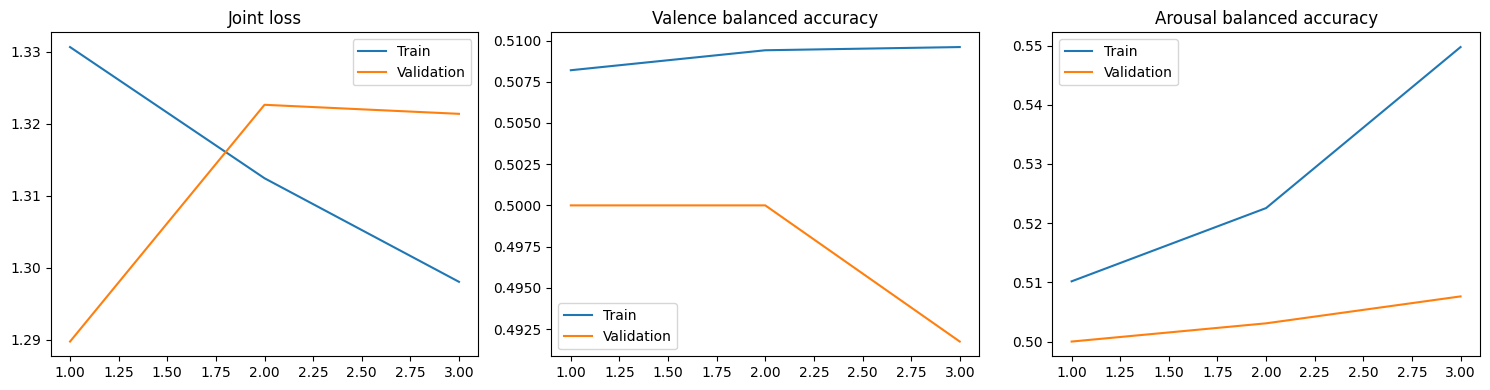

In [13]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
axes[0].plot(history_df.epoch, history_df.train_loss, label="Train")
axes[0].plot(history_df.epoch, history_df.val_loss, label="Validation")
axes[0].set_title("Joint loss"); axes[0].legend()
axes[1].plot(history_df.epoch, history_df.train_valence_bal_acc, label="Train")
axes[1].plot(history_df.epoch, history_df.val_valence_bal_acc, label="Validation")
axes[1].set_title("Valence balanced accuracy"); axes[1].legend()
axes[2].plot(history_df.epoch, history_df.train_arousal_bal_acc, label="Train")
axes[2].plot(history_df.epoch, history_df.val_arousal_bal_acc, label="Validation")
axes[2].set_title("Arousal balanced accuracy"); axes[2].legend()
plt.tight_layout(); plt.show()


VALENCE
              precision    recall  f1-score   support

         Low     0.7643    1.0000    0.8664      6206
        High     0.0000    0.0000    0.0000      1914

    accuracy                         0.7643      8120
   macro avg     0.3821    0.5000    0.4332      8120
weighted avg     0.5841    0.7643    0.6622      8120

AROUSAL
              precision    recall  f1-score   support

         Low     0.7429    1.0000    0.8525      6032
        High     0.0000    0.0000    0.0000      2088

    accuracy                         0.7429      8120
   macro avg     0.3714    0.5000    0.4262      8120
weighted avg     0.5518    0.7429    0.6333      8120

Valence accuracy: 0.7642857142857142 Macro-F1: 0.4331983805668016
Arousal accuracy: 0.7428571428571429 Macro-F1: 0.4262295081967213
Valence ROC-AUC: 0.5520527628401544
Arousal ROC-AUC: 0.49126573186936595


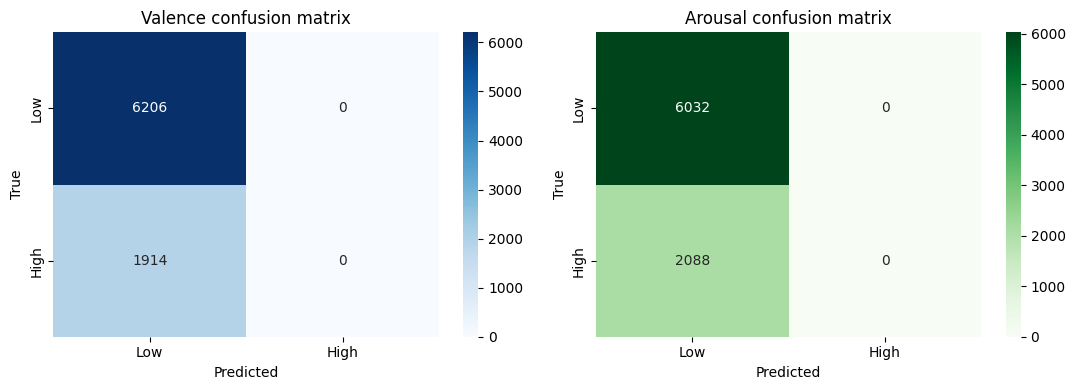

In [14]:

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score
)
import seaborn as sns

@torch.no_grad()
def predict(loader):
    model.eval()
    vt, vp, vprob = [], [], []
    at, ap, aprob = [], [], []

    for raw, freq, yv, ya in loader:
        raw, freq = raw.to(device), freq.to(device)
        vo, ao = model(raw, freq, spatial_prior_t)

        vt.extend(yv.numpy())
        vp.extend(vo.argmax(1).cpu().numpy())
        vprob.extend(torch.softmax(vo, dim=1)[:, 1].cpu().numpy())

        at.extend(ya.numpy())
        ap.extend(ao.argmax(1).cpu().numpy())
        aprob.extend(torch.softmax(ao, dim=1)[:, 1].cpu().numpy())

    return (
        np.asarray(vt), np.asarray(vp), np.asarray(vprob),
        np.asarray(at), np.asarray(ap), np.asarray(aprob)
    )

v_true, v_pred, v_prob, a_true, a_pred, a_prob = predict(test_loader)

print("VALENCE")
print(classification_report(
    v_true, v_pred, target_names=["Low", "High"], digits=4, zero_division=0
))
print("AROUSAL")
print(classification_report(
    a_true, a_pred, target_names=["Low", "High"], digits=4, zero_division=0
))

print("Valence accuracy:", accuracy_score(v_true, v_pred),
      "Macro-F1:", f1_score(v_true, v_pred, average="macro", zero_division=0))
print("Arousal accuracy:", accuracy_score(a_true, a_pred),
      "Macro-F1:", f1_score(a_true, a_pred, average="macro", zero_division=0))

if len(np.unique(v_true)) == 2:
    print("Valence ROC-AUC:", roc_auc_score(v_true, v_prob))
if len(np.unique(a_true)) == 2:
    print("Arousal ROC-AUC:", roc_auc_score(a_true, a_prob))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(
    confusion_matrix(v_true, v_pred), annot=True, fmt="d", cmap="Blues",
    xticklabels=["Low", "High"], yticklabels=["Low", "High"], ax=ax[0]
)
ax[0].set_title("Valence confusion matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")

sns.heatmap(
    confusion_matrix(a_true, a_pred), annot=True, fmt="d", cmap="Greens",
    xticklabels=["Low", "High"], yticklabels=["Low", "High"], ax=ax[1]
)
ax[1].set_title("Arousal confusion matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")
plt.tight_layout()
plt.show()


True valence: High
Recognized valence: Low
True arousal: Low
Recognized arousal: Low


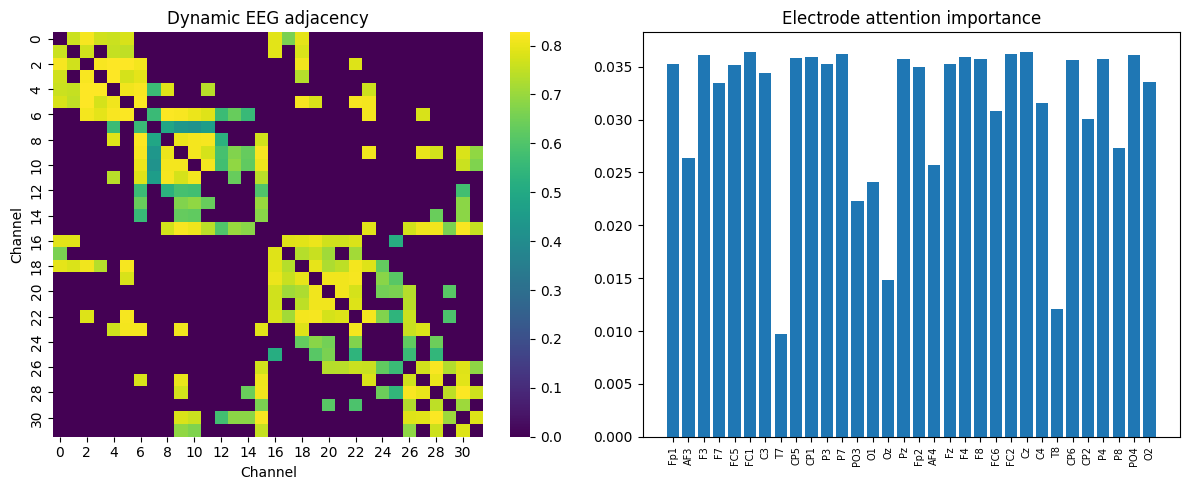

In [15]:
# Inspect the learned dynamic graph and electrode importance for one test sample.
@torch.no_grad()
def inspect_sample(ds, idx=0):
    model.eval(); raw,freq,yv,ya=ds[idx]
    out=model(raw.unsqueeze(0).to(device),freq.unsqueeze(0).to(device),spatial_prior_t,return_aux=True)
    return out, int(yv), int(ya)

out, true_v, true_a = inspect_sample(test_ds, 0)
adj=out["adjacency"][0].cpu().numpy(); importance=out["pool_weights"][0,:,0].cpu().numpy()
print("True valence:","High" if true_v else "Low")
print("Recognized valence:","High" if out["valence"].argmax(1).item() else "Low")
print("True arousal:","High" if true_a else "Low")
print("Recognized arousal:","High" if out["arousal"].argmax(1).item() else "Low")

fig,ax=plt.subplots(1,2,figsize=(12,5))
sns.heatmap(adj,cmap="viridis",ax=ax[0]); ax[0].set_title("Dynamic EEG adjacency"); ax[0].set_xlabel("Channel"); ax[0].set_ylabel("Channel")
ax[1].bar(np.arange(32),importance); ax[1].set_xticks(np.arange(32)); ax[1].set_xticklabels(CHANNEL_NAMES,rotation=90,fontsize=7); ax[1].set_title("Electrode attention importance")
plt.tight_layout(); plt.show()


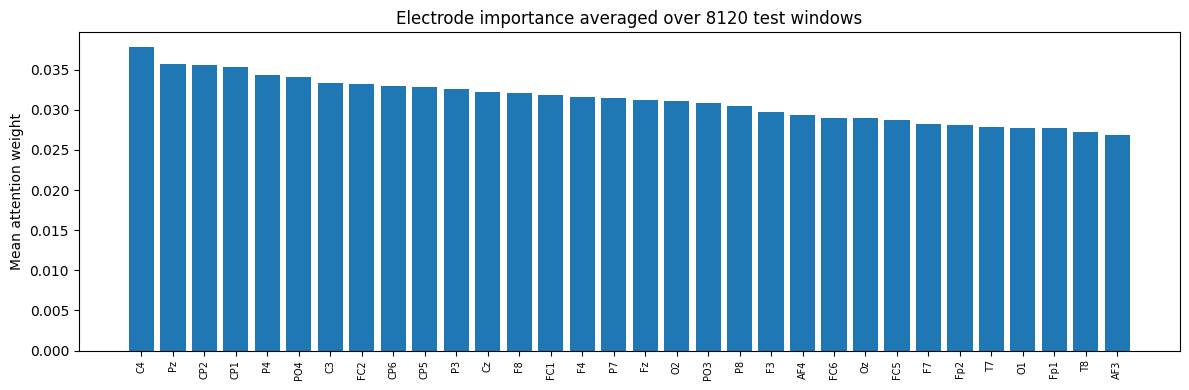

Top 8 electrodes by attention: ['C4', 'Pz', 'CP2', 'CP1', 'P4', 'PO4', 'C3', 'FC2']


In [16]:
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def aggregate_attention_and_graph(loader):
    """Average electrode attention weights and dynamic adjacency over an entire loader."""
    model.eval()
    attn_sum = np.zeros(len(CHANNEL_NAMES))
    adj_sum = np.zeros((len(CHANNEL_NAMES), len(CHANNEL_NAMES)))
    n = 0
    for raw, freq, yv, ya in loader:
        raw, freq = raw.to(device), freq.to(device)
        out = model(raw, freq, spatial_prior_t, return_aux=True)
        w = out["pool_weights"].squeeze(-1).cpu().numpy()  # [B, channels]
        a = out["adjacency"].cpu().numpy()                 # [B, channels, channels]
        attn_sum += w.sum(axis=0)
        adj_sum += a.sum(axis=0)
        n += raw.size(0)
    return attn_sum / n, adj_sum / n

mean_attn, mean_adj = aggregate_attention_and_graph(test_loader)

order = np.argsort(-mean_attn)
plt.figure(figsize=(12, 4))
plt.bar(range(len(CHANNEL_NAMES)), mean_attn[order])
plt.xticks(range(len(CHANNEL_NAMES)), [CHANNEL_NAMES[i] for i in order], rotation=90, fontsize=7)
plt.ylabel("Mean attention weight")
plt.title(f"Electrode importance averaged over {len(test_ds)} test windows")
plt.tight_layout()
plt.show()

print("Top 8 electrodes by attention:", [CHANNEL_NAMES[i] for i in order[:8]])

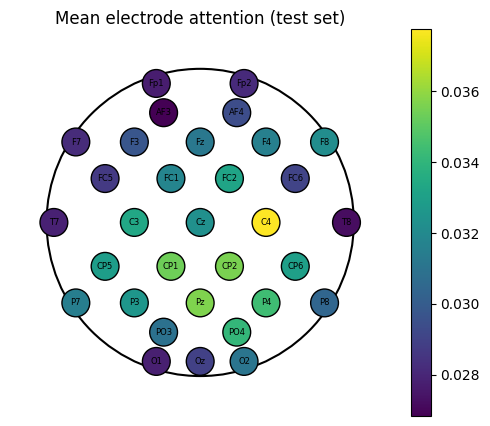

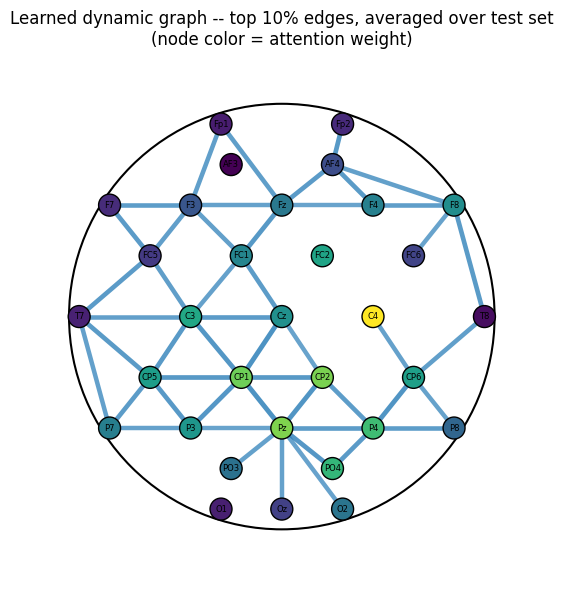

In [17]:
def scalp_scatter(values, title, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(5, 5))
    xs, ys = coords[:, 0], coords[:, 1]
    sca = ax.scatter(xs, ys, c=values, cmap=cmap, s=400, edgecolors="k", zorder=3)
    for i, ch in enumerate(CHANNEL_NAMES):
        ax.text(xs[i], ys[i], ch, ha="center", va="center", fontsize=6, zorder=4)
    ax.add_patch(plt.Circle((0, 0), 1.05, fill=False, linewidth=1.5))
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title)
    plt.colorbar(sca, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()

scalp_scatter(mean_attn, "Mean electrode attention (test set)")

# Network view of the averaged dynamic graph: draw the strongest 10% of edges.
fig, ax = plt.subplots(figsize=(6, 6))
xs, ys = coords[:, 0], coords[:, 1]
thresh = np.quantile(mean_adj[mean_adj > 0], 0.9)
for i in range(len(CHANNEL_NAMES)):
    for j in range(i + 1, len(CHANNEL_NAMES)):
        w = mean_adj[i, j]
        if w > thresh:
            ax.plot([xs[i], xs[j]], [ys[i], ys[j]], color="C0",
                     alpha=min(1.0, float(w) * 2), linewidth=1.5 + 5 * float(w))
ax.scatter(xs, ys, s=250, c=mean_attn, cmap="viridis", edgecolors="k", zorder=3)
for i, ch in enumerate(CHANNEL_NAMES):
    ax.text(xs[i], ys[i], ch, ha="center", va="center", fontsize=6, zorder=4)
ax.add_patch(plt.Circle((0, 0), 1.05, fill=False, linewidth=1.5))
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Learned dynamic graph -- top 10% edges, averaged over test set\n(node color = attention weight)")
plt.tight_layout(); plt.show()

### Integrated Gradients

Attention and the dynamic graph show what the model *looks at*, but not necessarily what actually moves a given prediction. Integrated Gradients accumulates the model's gradient along a straight-line path from a baseline input to the real input, giving a signed, per-input attribution that (approximately) sums to the change in the target logit.

The baseline is all-zeros, which — since `raw` and `freq` are z-scored per training statistics — corresponds to "average" signal, not "no" signal. That's the standard choice for normalized inputs.

In [18]:
def integrated_gradients(raw, freq, target_head, target_class, steps=32):
    """Integrated Gradients attribution w.r.t. one output head/class.

    raw:  [B, C, T] normalized raw-window batch
    freq: [B, C, F] normalized band-power batch
    target_head: "valence" or "arousal"
    target_class: 0 (Low) or 1 (High) -- the logit being attributed
    Returns (attr_raw, attr_freq) as numpy arrays, same shape as the inputs.
    """
    model.eval()
    raw = raw.to(device); freq = freq.to(device)
    baseline_raw = torch.zeros_like(raw)
    baseline_freq = torch.zeros_like(freq)

    total_grad_raw = torch.zeros_like(raw)
    total_grad_freq = torch.zeros_like(freq)

    for step in range(1, steps + 1):
        alpha = step / steps
        interp_raw = (baseline_raw + alpha * (raw - baseline_raw)).clone().requires_grad_(True)
        interp_freq = (baseline_freq + alpha * (freq - baseline_freq)).clone().requires_grad_(True)

        v, a = model(interp_raw, interp_freq, spatial_prior_t)
        logits = v if target_head == "valence" else a
        target = logits[:, target_class].sum()

        grad_raw, grad_freq = torch.autograd.grad(target, [interp_raw, interp_freq])
        total_grad_raw += grad_raw
        total_grad_freq += grad_freq

    avg_grad_raw = total_grad_raw / steps
    avg_grad_freq = total_grad_freq / steps

    attr_raw = (raw - baseline_raw) * avg_grad_raw
    attr_freq = (freq - baseline_freq) * avg_grad_freq
    return attr_raw.detach().cpu().numpy(), attr_freq.detach().cpu().numpy()

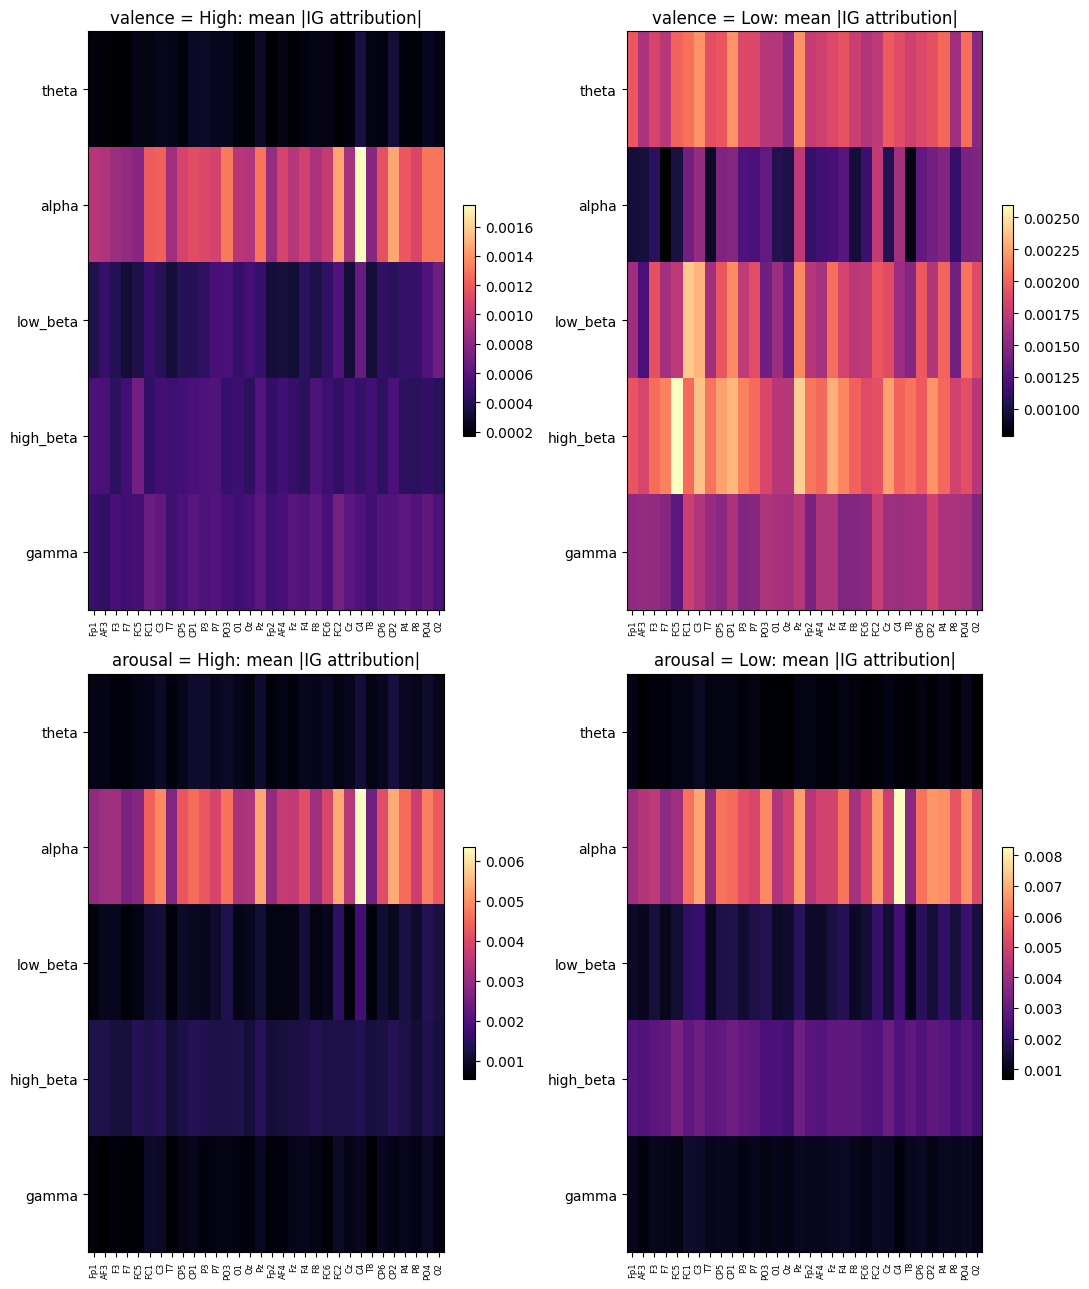

In [19]:
import random
random.seed(0)

sample_idx = random.sample(range(len(test_ds)), min(300, len(test_ds)))
raw_sub = torch.stack([test_ds[i][0] for i in sample_idx])
freq_sub = torch.stack([test_ds[i][1] for i in sample_idx])

band_names = list(BANDS.keys())
heatmaps = {}
for head in ["valence", "arousal"]:
    for cls, cls_name in [(1, "High"), (0, "Low")]:
        _, attr_freq = integrated_gradients(raw_sub, freq_sub, head, cls, steps=24)
        heatmaps[(head, cls_name)] = np.abs(attr_freq).mean(axis=0)  # [channels, bands]

fig, axes = plt.subplots(2, 2, figsize=(11, 13))
for ax, (head, cls_name) in zip(axes.flat, heatmaps.keys()):
    hm = heatmaps[(head, cls_name)]
    im = ax.imshow(hm.T, aspect="auto", cmap="magma")
    ax.set_yticks(range(len(band_names))); ax.set_yticklabels(band_names)
    ax.set_xticks(range(len(CHANNEL_NAMES))); ax.set_xticklabels(CHANNEL_NAMES, rotation=90, fontsize=6)
    ax.set_title(f"{head} = {cls_name}: mean |IG attribution|")
    plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout(); plt.show()

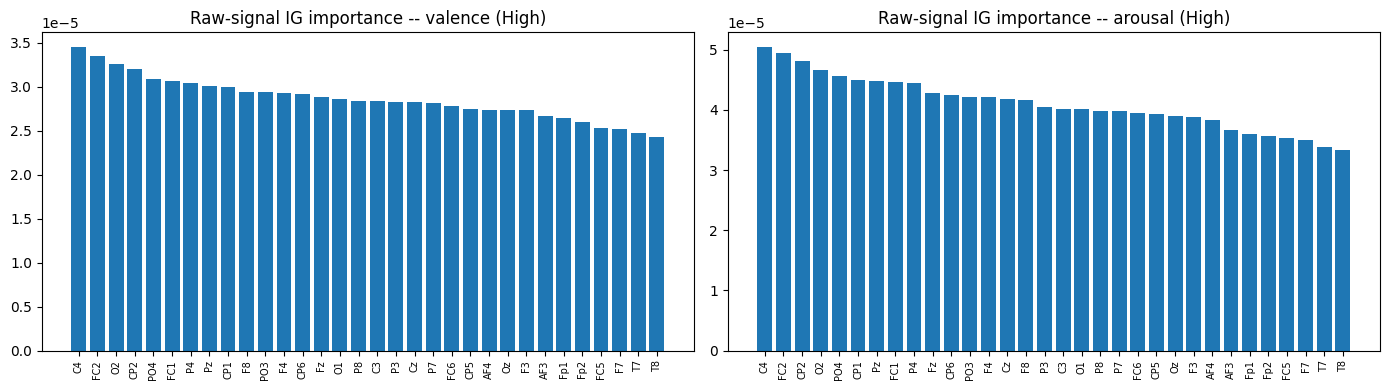

In [20]:
raw_importance = {}
for head in ["valence", "arousal"]:
    attr_raw, _ = integrated_gradients(raw_sub, freq_sub, head, 1, steps=24)  # class "High"
    raw_importance[head] = np.abs(attr_raw).mean(axis=(0, 2))  # mean over samples & time -> per channel

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, head in zip(axes, ["valence", "arousal"]):
    o = np.argsort(-raw_importance[head])
    ax.bar(range(len(CHANNEL_NAMES)), raw_importance[head][o])
    ax.set_xticks(range(len(CHANNEL_NAMES))); ax.set_xticklabels([CHANNEL_NAMES[i] for i in o], rotation=90, fontsize=7)
    ax.set_title(f"Raw-signal IG importance -- {head} (High)")
plt.tight_layout(); plt.show()

Correctly classified example:


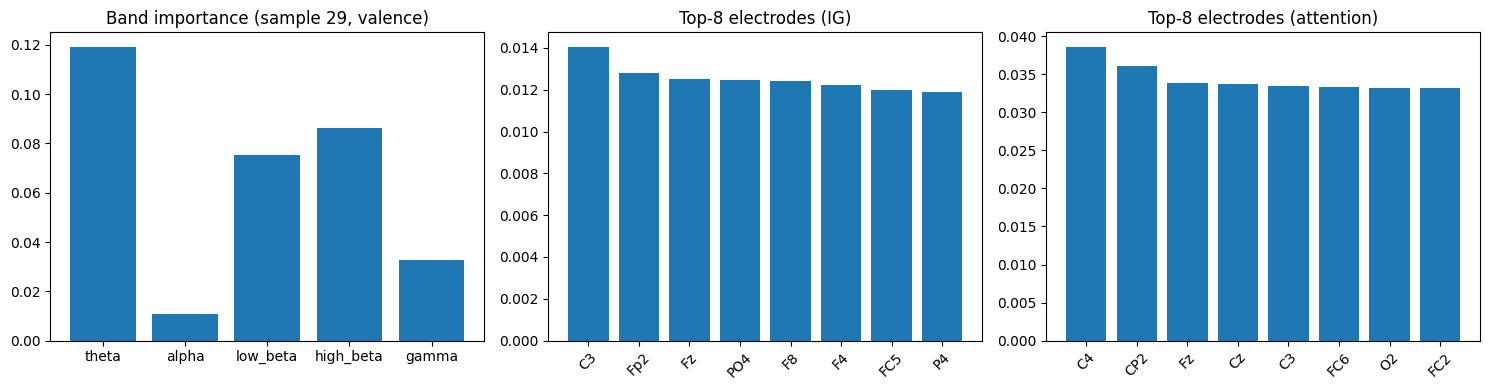

True valence: Low | Predicted: Low
Misclassified example:


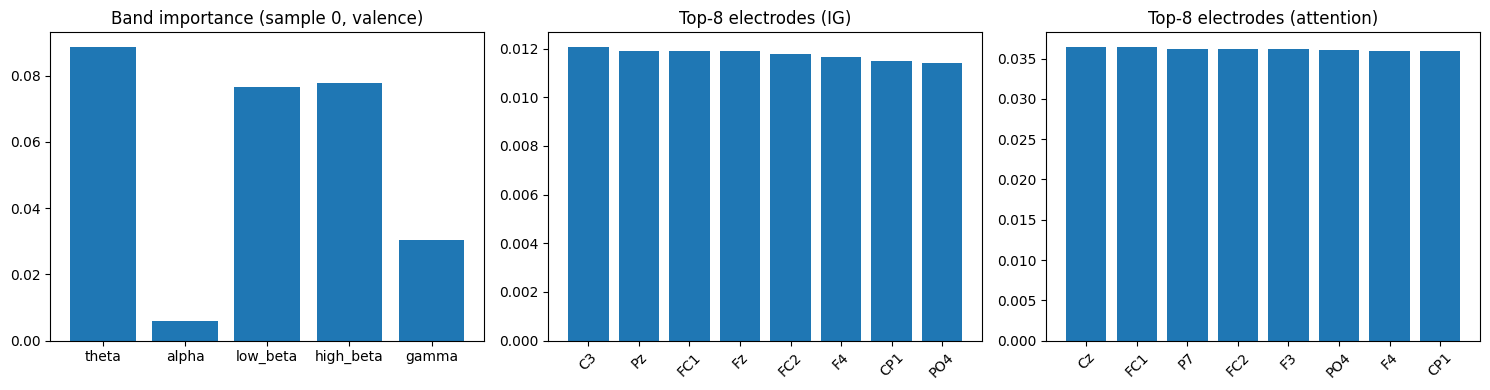

True valence: High | Predicted: Low


In [23]:
def explain_single(idx, head="valence"):
    raw, freq, yv, ya = test_ds[idx]
    raw_b, freq_b = raw.unsqueeze(0), freq.unsqueeze(0)
    out = model(raw_b.to(device), freq_b.to(device), spatial_prior_t, return_aux=True)
    pred_v = out["valence"].argmax(1).item()
    pred_a = out["arousal"].argmax(1).item()
    target_class = pred_v if head == "valence" else pred_a

    _, attr_freq = integrated_gradients(raw_b, freq_b, head, target_class, steps=32)
    band_importance = np.abs(attr_freq[0]).sum(axis=0)   # sum over channels -> per band
    chan_importance = np.abs(attr_freq[0]).sum(axis=1)   # sum over bands -> per channel

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].bar(band_names, band_importance)
    axes[0].set_title(f"Band importance (sample {idx}, {head})")

    o = np.argsort(-chan_importance)[:8]
    axes[1].bar(range(8), chan_importance[o])
    axes[1].set_xticks(range(8)); axes[1].set_xticklabels([CHANNEL_NAMES[i] for i in o], rotation=45)
    axes[1].set_title("Top-8 electrodes (IG)")

    w = out["pool_weights"][0, :, 0].cpu().detach().numpy()
    o2 = np.argsort(-w)[:8]
    axes[2].bar(range(8), w[o2])
    axes[2].set_xticks(range(8)); axes[2].set_xticklabels([CHANNEL_NAMES[i] for i in o2], rotation=45)
    axes[2].set_title("Top-8 electrodes (attention)")

    plt.tight_layout(); plt.show()
    true_label = yv if head == "valence" else ya
    print(f"True {head}:", "High" if int(true_label) else "Low", "| Predicted:", "High" if target_class else "Low")

# v_true / v_pred come from the evaluation cell above (test_loader has shuffle=False,
# so their order matches test_ds).
correct_mask = (v_true == v_pred)
incorrect_mask = ~correct_mask
correct_idx = int(np.where(correct_mask)[0][0])

print("Correctly classified example:")
explain_single(correct_idx, head="valence")

if incorrect_mask.any():
    incorrect_idx = int(np.where(incorrect_mask)[0][0])
    print("Misclassified example:")
    explain_single(incorrect_idx, head="valence")
else:
    print("No misclassified valence windows in the test set to show.")

In [24]:
import time
# Approximate inference cost.
model.eval(); raw_b,freq_b,_,_=next(iter(test_loader)); raw_b,freq_b=raw_b.to(device),freq_b.to(device)
with torch.no_grad():
    for _ in range(5): _=model(raw_b,freq_b,spatial_prior_t)
if device.type=="cuda": torch.cuda.synchronize()
t0=time.perf_counter()
with torch.no_grad():
    for _ in range(20): _=model(raw_b,freq_b,spatial_prior_t)
if device.type=="cuda": torch.cuda.synchronize()
elapsed=time.perf_counter()-t0
params=sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:",f"{params:,}")
print("Average inference/batch:",f"{elapsed/20*1000:.3f} ms")
print("Approx inference/sample:",f"{elapsed/20/raw_b.size(0)*1000:.3f} ms")

checkpoint={"model_state_dict":model.state_dict(),"spatial_prior":spatial_weight, "raw_mean":raw_mean, "raw_std":raw_std, "freq_mean":freq_mean, "freq_std":freq_std,"channel_names":CHANNEL_NAMES,
            "config":{"EEG_CHANNELS":32,"FS":128,"BASELINE_SEC":3,"WINDOW_SEC":4,"LABEL_THRESHOLD":5.0,
                      "MAX_SUBJECTS":MAX_SUBJECTS,"D_MODEL":64,"N_HEADS":4,"N_TEMP_LAYERS":2,"N_GRAPH_LAYERS":2,
                      "TOP_K_DYNAMIC":5,"SPATIAL_BIAS":0.5}}
torch.save(checkpoint,"Group9_Dataset3__bestmodel.pt")
print("Saved: Group9_Dataset3_bestmodel.pt")


Trainable parameters: 49,366
Average inference/batch: 198.234 ms
Approx inference/sample: 0.774 ms
Saved: Group9_Dataset3_bestmodel.pt


In [25]:
import torch

# 1. Load the .pt file
data = torch.load("/content/Group9_Dataset3__bestmodel.pt", map_location="cpu", weights_only=False)

# 2. View the type of data stored (usually a dict or a tensor)
print("Data Type:", type(data))

# 3. Inspect the contents
if isinstance(data, dict):
    # If it is a state_dict (weights and biases), print the layer names
    print("Keys/Layers found:")
    print(data.keys())
else:
    # If it is a raw tensor, print its shape and values
    print("Tensor Shape:", data.shape)
    print(data)

Data Type: <class 'dict'>
Keys/Layers found:
dict_keys(['model_state_dict', 'spatial_prior', 'raw_mean', 'raw_std', 'freq_mean', 'freq_std', 'channel_names', 'config'])
